In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast

In [27]:
df = pd.read_csv('../results/evaluation_results.csv')

In [28]:
eval_columns = {
    'multi_agent_eval': 'Multi-Agent P&S',
    'cot_agent_eval': 'Chain-of-Thought',
    'plan_and_solve_eval': 'Single-Agent P&S'
}

long_df = df.melt(
    id_vars=['task_id'], 
    value_vars=list(eval_columns.keys()),
    var_name='strategy_raw', 
    value_name='raw_status_str'
)

In [29]:
def parse_status(val):
    try:
        # Converts "{'status': 'passed', ...}" string into a real Python dict
        status_dict = ast.literal_eval(str(val))
        return 1 if status_dict.get('status') == 'passed' else 0
    except (ValueError, SyntaxError):
        return 0

In [30]:
long_df['strategy'] = long_df['strategy_raw'].map(eval_columns)
long_df['is_pass'] = long_df['raw_status_str'].apply(parse_status)

C:\Users\5325n\AppData\Local\Temp\ipykernel_66844\812149489.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


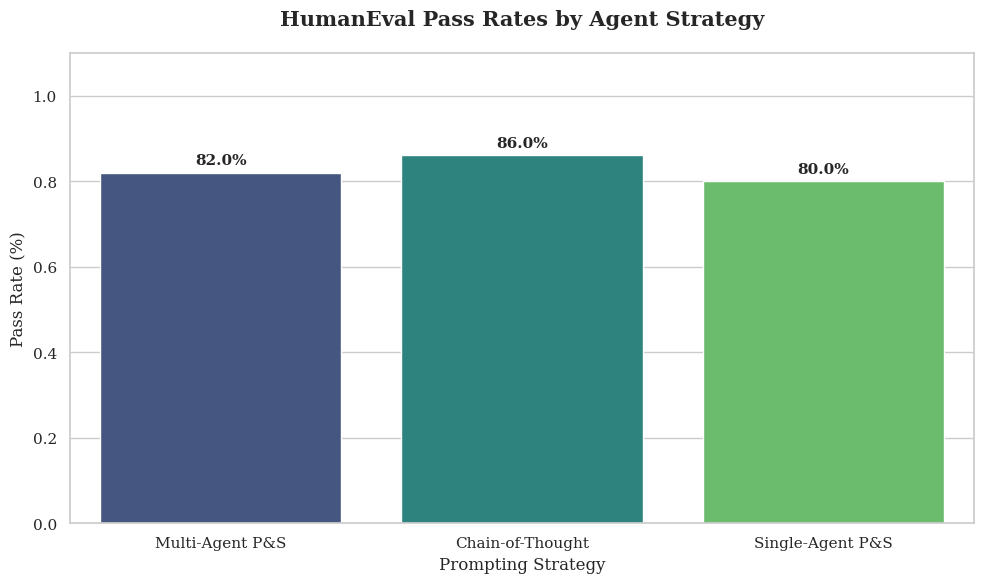

In [31]:
sns.set_theme(style="whitegrid", font="serif")
plt.figure(figsize=(10, 6))

# Calculate the mean (pass rate) automatically
ax = sns.barplot(
    data=long_df, 
    x='strategy', 
    y='is_pass', 
    palette='viridis', 
    errorbar=None
)

# 6. Final Formatting
plt.title('HumanEval Pass Rates by Agent Strategy', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Pass Rate (%)', fontsize=12)
plt.xlabel('Prompting Strategy', fontsize=12)
plt.ylim(0, 1.1)  # Scale slightly above 100% for labels

# Add percentage labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1%}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontweight='bold', 
                fontsize=11)

plt.tight_layout()
plt.savefig('strategy_comparison_chart.png', dpi=300)
plt.show()

C:\Users\5325n\AppData\Local\Temp\ipykernel_66844\3809590974.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


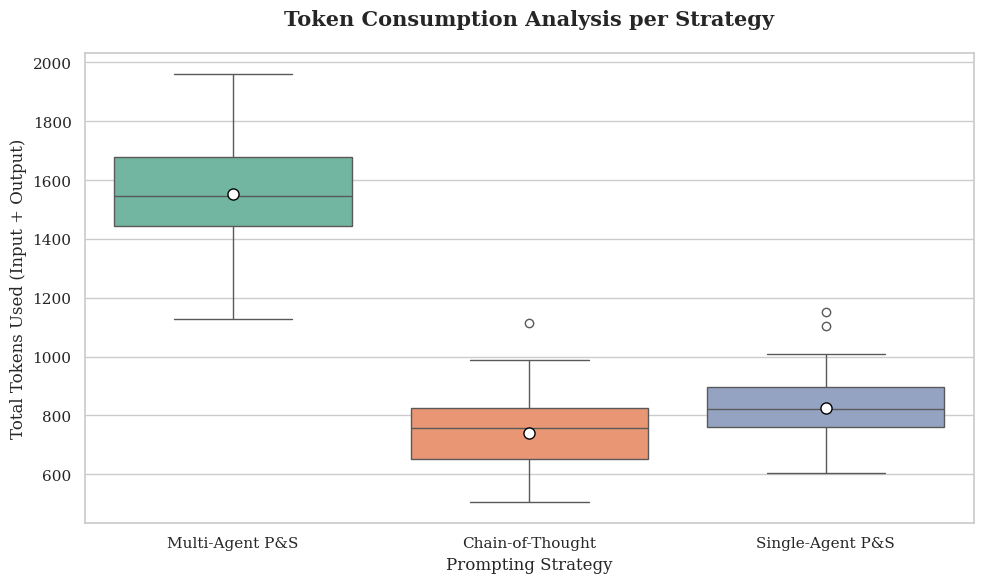

Average Token Usage by Strategy:
strategy
Chain-of-Thought     741.14
Multi-Agent P&S     1553.84
Single-Agent P&S     825.96
Name: token_count, dtype: float64


In [32]:
token_columns = {
    'multi_agent_tokens': 'Multi-Agent P&S',
    'cot_agent_tokens': 'Chain-of-Thought',
    'plan_and_solve_tokens': 'Single-Agent P&S'
}

token_df = df.melt(
    id_vars=['task_id'], 
    value_vars=list(token_columns.keys()),
    var_name='strategy_raw', 
    value_name='token_count'
)

token_df['strategy'] = token_df['strategy_raw'].map(token_columns)

# 5. Plotting
sns.set_theme(style="whitegrid", font="serif")
plt.figure(figsize=(10, 6))

# Boxplot shows the distribution of costs
sns.boxplot(
    data=token_df, 
    x='strategy', 
    y='token_count', 
    palette='Set2',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# 6. Final Formatting
plt.title('Token Consumption Analysis per Strategy', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Total Tokens Used (Input + Output)', fontsize=12)
plt.xlabel('Prompting Strategy', fontsize=12)

plt.tight_layout()
plt.savefig('token_usage_chart.png', dpi=300)
plt.show()

# Print the average cost for your report
print("Average Token Usage by Strategy:")
print(token_df.groupby('strategy')['token_count'].mean().round(2))

In [ ]:
def categorize_error(val):
    try:
        data = ast.literal_eval(str(val))
        if data.get('status') == 'passed':
            return 'Passed'
        
        err_msg = str(data.get('error', '')).lower()
        if 'timeout' in err_msg:
            return 'Timeout'
        elif 'syntaxerror' in err_msg or 'invalid syntax' in err_msg:
            return 'Syntax Error'
        elif 'assertionerror' in err_msg:
            return 'Assertion (Logic) Error'
        elif 'nameerror' in err_msg:
            return 'Name/Import Error'
        else:
            return 'Timeout'
    except:
        return 'Data Error'

# Apply to your long_df from the previous step
long_df['error_category'] = long_df['raw_status_str'].apply(categorize_error)

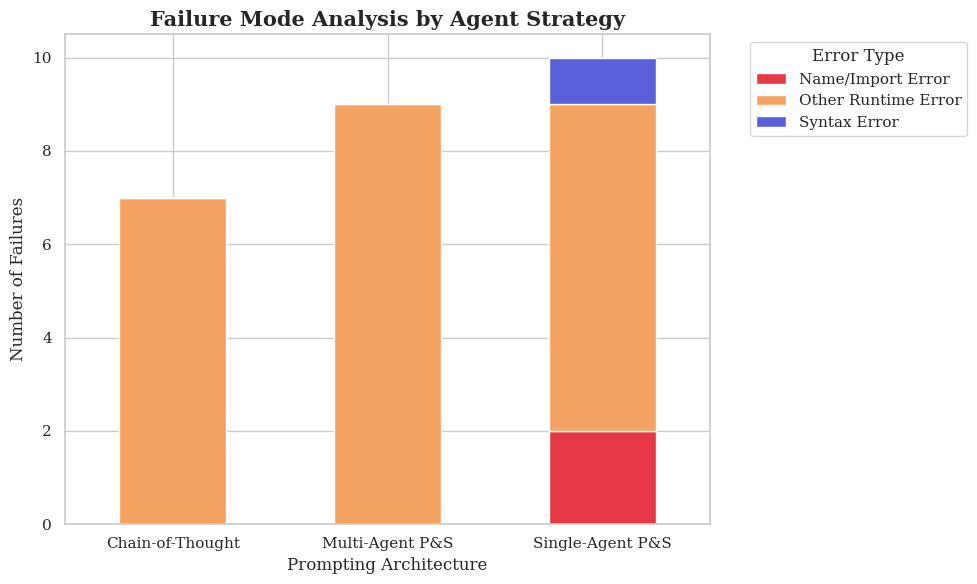

In [34]:
custom_colors = ['#e63946', '#f4a261', "#5a60da"]

# 1. Filter for only failures
failure_df = long_df[long_df['error_category'] != 'Passed'].copy()

# 2. Pivot the data for a stacked bar chart
error_counts = failure_df.groupby(['strategy', 'error_category']).size().unstack(fill_value=0)

# 3. Plotting
sns.set_theme(style="whitegrid", font="serif")
error_counts.plot(kind='bar', stacked=True, figsize=(10, 6), color = custom_colors[:len(error_counts.columns)])

# 4. Aesthetics
plt.title('Failure Mode Analysis by Agent Strategy', fontsize=15, fontweight='bold')
plt.ylabel('Number of Failures', fontsize=12)
plt.xlabel('Prompting Architecture', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Error Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('failure_analysis_stacked.png', dpi=300)
plt.show()